# Proyek Klasifikasi Gambar: Vegetable Images Dataset
- **Nama:** Rafi Widyansyah
- **Email:** dompetakun@gmail.com
- **ID Dicoding:** rafiwidyansyah

## Import Semua Packages/Library yang Digunakan

In [ ]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm as tq

import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import tensorflowjs
from keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"rafiwidyansyah","key":"58828d9227b663929718fc049119317d"}'}

In [5]:
# download dataset dari kaggle
!kaggle datasets download -d misrakahmed/vegetable-image-dataset

Dataset URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
License(s): CC-BY-SA-4.0
vegetable-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip vegetable-image-dataset.zip

#### Penentuan Direktori Awal Data Train, Data Test, dan Gabungan Kedua Data

In [7]:
# Direktori Train Data dan Test Data
train_direct = "Vegetable Images/train"
test_direct  = "Vegetable Images/validation"

In [8]:
# Direktori Train-Test
join_dir = "Vegetable Images/dataset"

In [9]:
# Membuat directory gabungan dengan perintah os.makedirs()
os.makedirs(join_dir, exist_ok=True)

#### Salin File dan Folder Dataset Dari Direktori Train dan Test ke dalam Direktori Dataset yang telah dibuat.

In [10]:
# Salin file dan folder dari train
for category in os.listdir(train_direct):
    category_dir = os.path.join(train_direct, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(join_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_direct):
    category_dir = os.path.join(test_direct, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(join_dir, category), dirs_exist_ok=True)

### Data Preprocessing

#### Tampilkan 5 gambar sayuran secara acak.

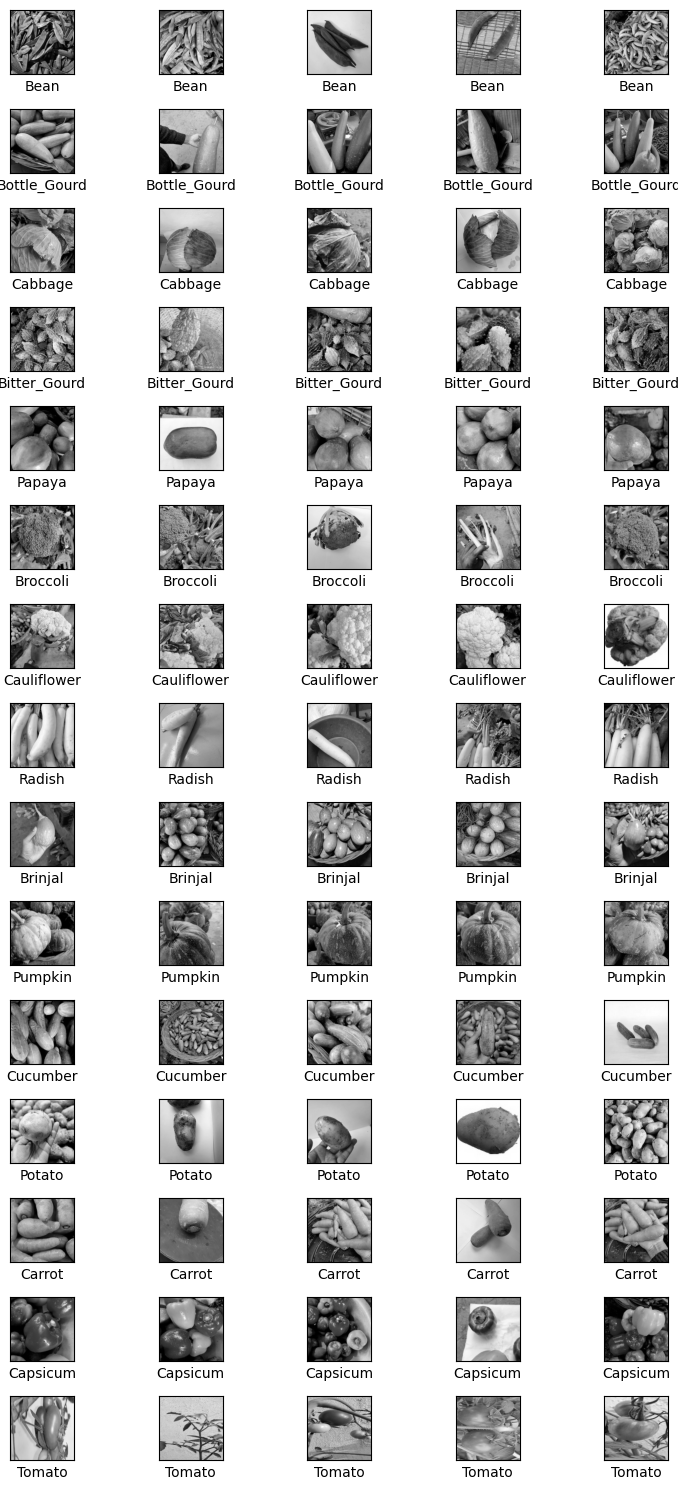

In [11]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
vegetable_images = {}

path = "Vegetable Images"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    vegetable_images[i] = []
    for j in os.listdir(os.path.join(path_sub, i)):
        vegetable_images[i].append(os.path.join(path_sub, i, j))

# Menampilkan secara acak 10 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(vegetable_images.keys()), 10, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    num_images_in_class = len(vegetable_images[class_name])
    if num_images_in_class == 0:
        print(f"No images found for class: {class_name}. Skipping.")
        for j in range(10):
            axs[i, j].set_visible(False)
        continue

    # Sample at most 5 images, or fewer if the class has less than 5
    num_samples = min(5, num_images_in_class)
    images = np.random.choice(vegetable_images[class_name], num_samples, replace=False)

    for j, image_name in enumerate(images):
        img_path = image_name  # Corrected: image_name already holds the full path
        try:
            img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
            axs[i, j].imshow(img, cmap='gray')
            axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])
        except FileNotFoundError:
            print(f"Error: Image file not found at {img_path}. Skipping.")
            axs[i, j].set_visible(False) # Hide the subplot if image not found

    # Hide unused subplots in the row if less than 10 images were displayed
    for j in range(num_samples, 10):
        axs[i, j].set_visible(False)

fig.tight_layout()

#### Plot Distribusi Dataset

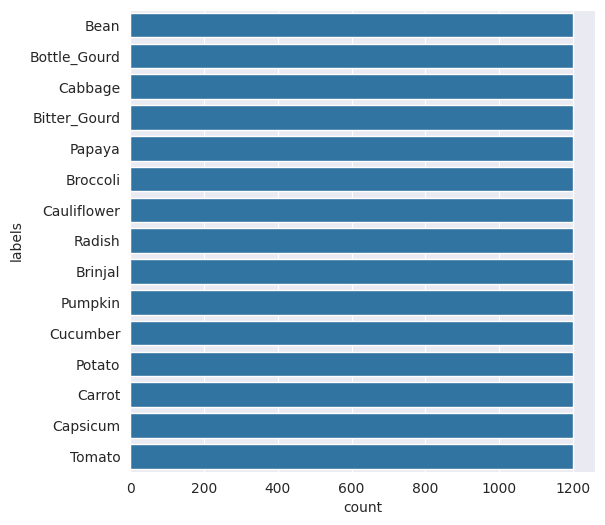

In [12]:
# Definisikan path sumber
veg_path = "Vegetable Images/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(veg_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

#### Split Dataset

In [19]:
#!pip install split-folders

import splitfolders

splitfolders.ratio(
    join_dir,
    output='Vegetable Images/split-data',
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)
TRAIN_DIR = 'Vegetable Images/split-data/train'
VAL_DIR   = 'Vegetable Images/split-data/val'
TEST_DIR  = 'Vegetable Images/split-data/test'

Copying files: 18000 files [00:07, 2472.51 files/s]


### Create Image Data Generators

In [24]:
# Define image dimensions and batch size
img_height, img_width = 64, 64
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(img_height,img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(img_height,img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(img_height,img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)


Found 14400 images belonging to 15 classes.
Found 1800 images belonging to 15 classes.
Found 1800 images belonging to 15 classes.


## Modelling

In [25]:
# Membuat Model CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3), kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),

    layers.Dense(15, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# setup learning rate dan early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", mode='min', min_delta=0.1, patience=10, restore_best_weights=True)

# Determine Optimizer & Loss Function
model.compile(optimizer=tf.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,099,919 (8.01 MB)

 Trainable params: 2,098,959 (8.01 MB)

 Non-trainable params: 960 (3.75 KB)

In [27]:
# Train model
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=30,
                    callbacks=[early_stopping,reduce_lr],
                    verbose=1)

Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 46s 81ms/step - accuracy: 0.6544 - loss: 6.2355 - val_accuracy: 0.2733 - val_loss: 3.9074 - learning_rate: 0.0010
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.7680 - loss: 1.6701 - val_accuracy: 0.5339 - val_loss: 2.5140 - learning_rate: 0.0010
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.8210 - loss: 1.3770 - val_accuracy: 0.4017 - val_loss: 2.8510 - learning_rate: 0.0010
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.8429 - loss: 1.2757 - val_accuracy: 0.6178 - val_loss: 2.0111 - learning_rate: 0.0010
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.8590 - loss: 1.2155 - val_accuracy: 0.5517 - val_loss: 2.3110 - learning_rate: 0.0010
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8624 - loss: 1.1773
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
450/450 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.8628 - los

## Evaluasi dan Visualisasi

In [28]:
# Evaluasi model
loss, accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {accuracy*100:.2f}%')

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9794 - loss: 0.2988
Test Accuracy: 97.94%


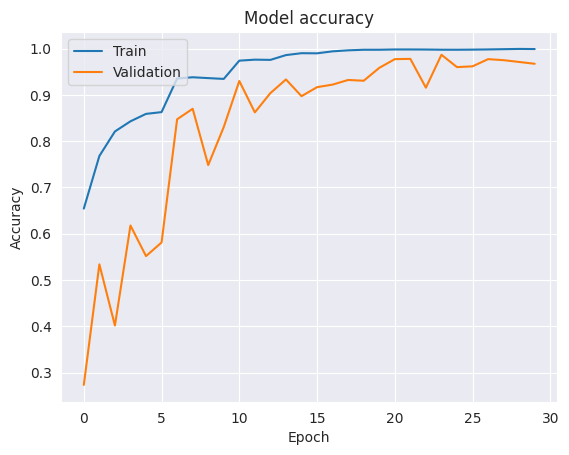

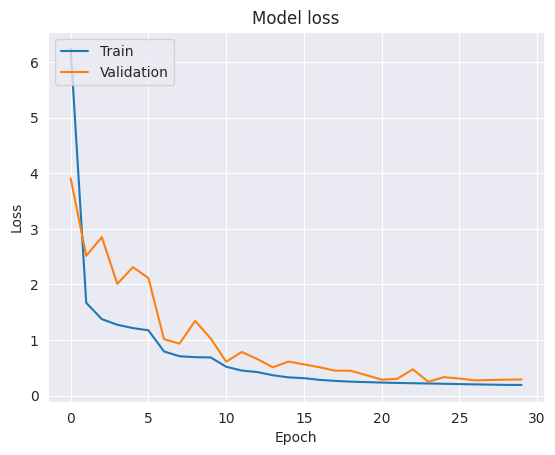

In [29]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Konversi Model

In [30]:
# Menyimpan model dalam format SavedModel (direkomendasikan untuk deployment)
model.export("vegetable_image_classification_savedmodel")

Saved artifact at 'vegetable_image_classification_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  135140491769040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491769808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491770192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491770384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491770000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491769232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491769616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491768080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491768464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135140491771536: TensorSpec(shape=(), dtype=tf.resource, 

In [31]:
# Mengonversi model yang disimpan dalam format SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model("vegetable_image_classification_savedmodel")
tflite_model = converter.convert()

# Direktori untuk menyimpan model TFLite
tflite_output_dir = "tflite_models"
os.makedirs(tflite_output_dir, exist_ok=True)

# Menyimpan model yang dikonversi ke file .tflite di dalam direktori baru
with open(os.path.join(tflite_output_dir, "vegetable_image_classification.tflite"), "wb") as f:
    f.write(tflite_model)

In [7]:
# Save Model ke dalam tfjs
#!pip install tensorflowjs

# Direktori tempat SavedModel disimpan
saved_model_dir = "vegetable_image_classification_savedmodel"

# Direktori output untuk model TF.js
tfjs_output_dir = "vegetable_image_classification_tfjs"

# Mengonversi SavedModel ke format TF.js
tensorflowjs.converters.convert_tf_saved_model(saved_model_dir, tfjs_output_dir)